In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import sys
import os

sys.path.append("..") 
from rl_engine.environment import K8sSecurityEnv

# Configuration
MODELS_DIR = "../controller/models_dist"
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [8]:
def train_and_plot_agent(episodes=1000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env = K8sSecurityEnv()
    
    model = DQN(env.observation_space.shape[0], env.action_space.n).to(device)
    target_model = DQN(env.observation_space.shape[0], env.action_space.n).to(device)
    target_model.load_state_dict(model.state_dict())
    
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.MSELoss()
    
    memory = deque(maxlen=10000)
    epsilon = 1.0
    epsilon_decay = 0.995
    epsilon_min = 0.01
    gamma = 0.99
    batch_size = 64
    target_update_freq = 10 
    
    scores = []
    print(f"Starting RL Training for {episodes} episodes on {device}...")

    for e in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            if np.random.rand() <= epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    q_values = model(state_t)
                    action = torch.argmax(q_values).item()

            next_state, reward, done, _ = env.step(action)
            memory.append((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward

            if len(memory) > batch_size:
                batch = random.sample(memory, batch_size)
                
                states_t = torch.FloatTensor(np.array([x[0] for x in batch])).to(device)
                actions_t = torch.LongTensor(np.array([x[1] for x in batch])).unsqueeze(1).to(device)
                rewards_t = torch.FloatTensor(np.array([x[2] for x in batch])).to(device)
                next_states_t = torch.FloatTensor(np.array([x[3] for x in batch])).to(device)
                dones_t = torch.FloatTensor(np.array([x[4] for x in batch])).to(device)

                current_q = model(states_t).gather(1, actions_t).squeeze()
                
                with torch.no_grad():
                    max_next_q = target_model(next_states_t).max(1)[0]
                    target_q = rewards_t + (gamma * max_next_q * (1 - dones_t))

                loss = criterion(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if e % target_update_freq == 0:
            target_model.load_state_dict(model.state_dict())

        if epsilon > epsilon_min:
            epsilon *= epsilon_decay
            
        scores.append(total_reward)
        if e % 100 == 0:
            print(f"Episode {e} | Reward: {total_reward:.2f} | Epsilon: {epsilon:.2f}")

    torch.save(model.state_dict(), f"{MODELS_DIR}/dqn_agent.pth")
    print("Agent Saved.")
    return scores

# Run Training
scores = train_and_plot_agent(episodes=1000)

Starting RL Training for 1000 episodes on cpu...
Episode 0 | Reward: -93.00 | Epsilon: 0.99
Episode 100 | Reward: 218.00 | Epsilon: 0.60
Episode 200 | Reward: 219.00 | Epsilon: 0.37
Episode 300 | Reward: 396.00 | Epsilon: 0.22
Episode 400 | Reward: 408.00 | Epsilon: 0.13
Episode 500 | Reward: 455.00 | Epsilon: 0.08
Episode 600 | Reward: 359.00 | Epsilon: 0.05
Episode 700 | Reward: 418.00 | Epsilon: 0.03
Episode 800 | Reward: 334.00 | Epsilon: 0.02
Episode 900 | Reward: 475.00 | Epsilon: 0.01
Agent Saved.


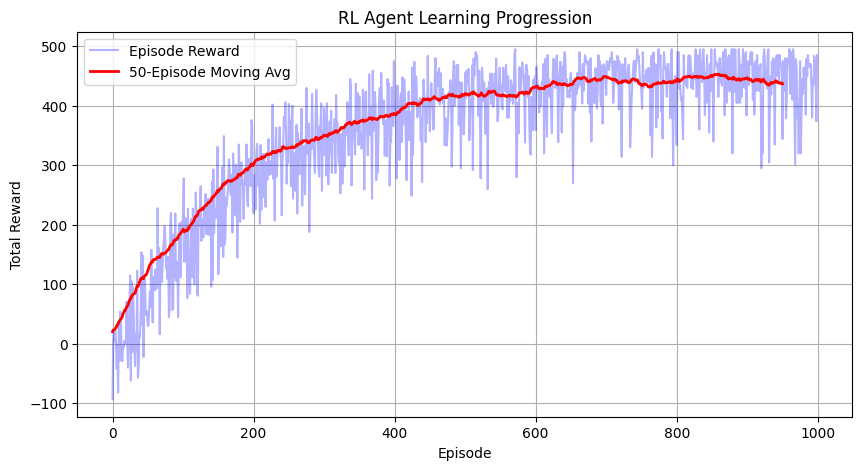

In [9]:
# Plotting the Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(scores, label='Episode Reward', color='blue', alpha=0.3)

# Calculate Moving Average
moving_avg = np.convolve(scores, np.ones(50)/50, mode='valid')
plt.plot(range(len(moving_avg)), moving_avg, label='50-Episode Moving Avg', color='red', linewidth=2)

plt.title('RL Agent Learning Progression')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()